In [28]:
!pip install pandas scikit-learn matplotlib

In [4]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, make_scorer, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

In [5]:
# --- CONFIGURATION & PATH SETUP ---

RANDOM_STATE = 42

DATA_FILE_PATH = "/processed_feature_selected.csv"
ARTIFACTS_DIR = "deployment_artifacts"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

In [6]:
# 1. Load the data
print("1. Loading and preparing data...")
try:
    df = pd.read_csv(DATA_FILE_PATH)
except FileNotFoundError:
    print(f"Error: Dataset not found at path: {DATA_FILE_PATH}")
    print("Please ensure the file is uploaded to Colab or update DATA_FILE_PATH.")
    exit()

1. Loading and preparing data...


In [7]:
# Target Creation: 1 (Healthy), 0 (Unhealthy) based on median health_score
median_score = df['health_score'].median()
df['healthiness'] = (df['health_score'] >= median_score).astype(int)
y = df['healthiness']

In [10]:
# Define Initial Features (X)
features_to_drop = ['title', 'health_score', 'healthiness', 'fat_level']
X_base = df.drop(columns=features_to_drop)

In [11]:
# Split data before Feature Engineering
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"   Train samples: {len(X_train_raw)}, Test samples: {len(X_test_raw)}")

   Train samples: 8495, Test samples: 2124


In [12]:
# 2. Feature Engineering Section (Polynomial features - Degree 2)
print("2. Applying Feature Engineering (Polynomial Features)...")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

feature_names = poly.get_feature_names_out(X_train_raw.columns)
X_train = pd.DataFrame(X_train_poly, columns=feature_names)
X_test = pd.DataFrame(X_test_poly, columns=feature_names)

2. Applying Feature Engineering (Polynomial Features)...


In [13]:
# 3. Handle any missing values
print("3. Handling missing values (using SimpleImputer)...")
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

3. Handling missing values (using SimpleImputer)...


In [14]:
# 4. Scale features
print("4. Scaling features (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
print(f"   Total features after engineering and scaling: {X_train_scaled.shape[1]}")

4. Scaling features (StandardScaler)...
   Total features after engineering and scaling: 44


In [15]:
# 5. Basic GBM Model (Used for Comparison)
print("\n5. Training Basic GBM Model (max_depth=3, 100 est.)...")
basic_gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE)
basic_gbm.fit(X_train_scaled, y_train)

y_pred_basic_val = basic_gbm.predict(X_test_scaled)
f1_basic_val = f1_score(y_test, y_pred_basic_val)
print(f"   Basic Model Test F1-Score: {f1_basic_val:.4f}")


5. Training Basic GBM Model (max_depth=3, 100 est.)...
   Basic Model Test F1-Score: 0.9816


In [16]:
# 6. Tuned GBM Model (Hyperparameter Tuning)
print("\n6. Starting Tuned GBM Model (GridSearchCV)...")
param_grid = {
    'n_estimators': [150, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
tuned_gbm = grid_search.best_estimator_
print(f"   Tuning complete. Best Parameters: {grid_search.best_params_}")



6. Starting Tuned GBM Model (GridSearchCV)...
   Tuning complete. Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}


In [17]:
# 7. Evaluate Tuned Model
y_pred_tuned_test = tuned_gbm.predict(X_test_scaled)
y_proba_tuned_test = tuned_gbm.predict_proba(X_test_scaled)[:, 1]

In [18]:
# 8. Comparison DataFrame for Basic vs Tuned
comparison_data = {
    'Model': ['Basic GBM (Test)', 'Tuned GBM (Test)'],
    'F1-Score': [f1_basic_val, f1_score(y_test, y_pred_tuned_test)],
    'Accuracy': [accuracy_score(y_test, y_pred_basic_val), accuracy_score(y_test, y_pred_tuned_test)]
}
comparison_df = pd.DataFrame(comparison_data)
print("\n8. Comparison DataFrame (Basic vs Tuned on Test Set):\n", comparison_df)


8. Comparison DataFrame (Basic vs Tuned on Test Set):
               Model  F1-Score  Accuracy
0  Basic GBM (Test)  0.981578  0.981638
1  Tuned GBM (Test)  0.984891  0.984934


In [19]:
# 9. Full Metrics Table for Tuned Model (Final Selection)
metrics_tuned_test = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned_test),
    'Precision': precision_score(y_test, y_pred_tuned_test),
    'Recall': recall_score(y_test, y_pred_tuned_test),
    'F1-Score': f1_score(y_test, y_pred_tuned_test),
    'AUC': roc_auc_score(y_test, y_proba_tuned_test)
}
print("\n9. Full Metrics Table for Tuned GBM (Test Set):\n")
metrics_series = pd.Series(metrics_tuned_test)
print(metrics_series.to_markdown())


9. Full Metrics Table for Tuned GBM (Test Set):

|           |        0 |
|:----------|---------:|
| Accuracy  | 0.984934 |
| Precision | 0.987689 |
| Recall    | 0.982109 |
| F1-Score  | 0.984891 |
| AUC       | 0.998584 |


In [20]:
# 10. Visualization (Confusion Matrix and ROC Curve)
print("\n10. Generating Visualizations...")


10. Generating Visualizations...


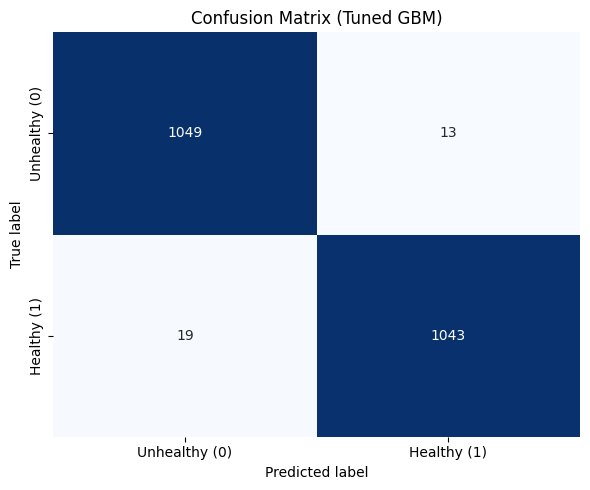

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Unhealthy (0)', 'Healthy (1)'],
            yticklabels=['Unhealthy (0)', 'Healthy (1)'])
plt.title('Confusion Matrix (Tuned GBM)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

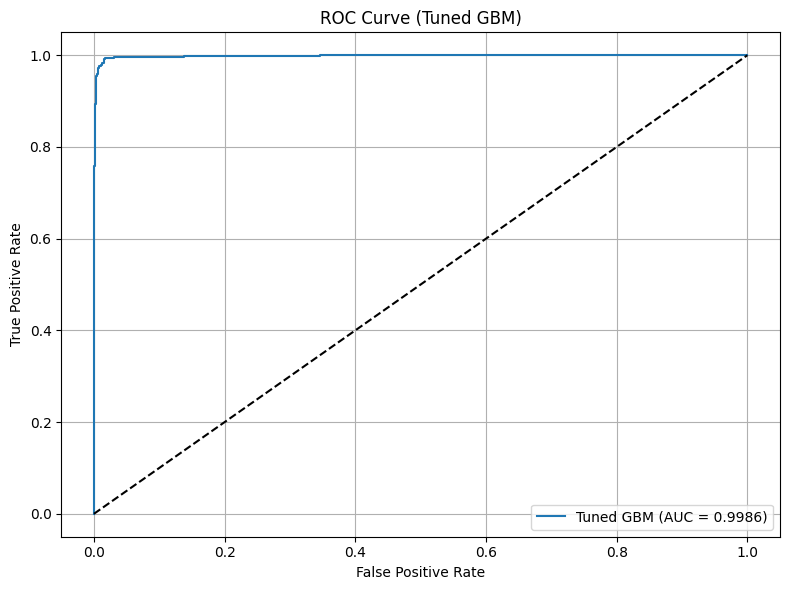

In [22]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Tuned GBM (AUC = {metrics_tuned_test["AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Tuned GBM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# 11. Save tuned model, scaler, and final feature list
print("\n11. Saving Tuned Model Artifacts...")
final_feature_list = X_train_scaled.columns.tolist()


11. Saving Tuned Model Artifacts...


In [24]:
joblib.dump(tuned_gbm, os.path.join(ARTIFACTS_DIR, 'final_gbm_model.joblib'))
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, 'scaler.joblib'))
joblib.dump(final_feature_list, os.path.join(ARTIFACTS_DIR, 'model_features.joblib'))

['deployment_artifacts/model_features.joblib']

In [25]:
print(f"\n✅ All artifacts saved to the '{ARTIFACTS_DIR}' folder.")


✅ All artifacts saved to the 'deployment_artifacts' folder.
